# **LAB2: Predicción de Fallos y Detección de Data Drift**

En esta práctica abordaremos dos problemas fundamentales en Machine Learning: entrenar un modelo predictivo robusto y validar que los datos con los que trabajamos son consistentes en el tiempo.


## 📖 Contexto de la Práctica
Este conjunto de datos representa los resultados de un amplio estudio de pruebas de productos industriales. Para cada código de producto (`product_code`), se proporcionan:
* **Atributos (`attributes`)**: Características fijas para cada código de producto.
* **Mediciones (`measurement`)**: Valores individuales para cada producto, representando distintos métodos de pruebas de laboratorio.

Cada producto se somete a un experimento que simula un entorno del mundo real, en el que absorbe una cierta cantidad de fluido (`loading`) para comprobar si el producto falla o resiste.


## 🔍 Análisis Exploratorio de Datos (EDA)

Antes de construir cualquier modelo predictivo, es fundamental comprender la naturaleza de nuestros datos. En esta sección realizaremos un Análisis Exploratorio de Datos (EDA) para:
1. Conocer la estructura y los tipos de datos.
2. Identificar la presencia de valores nulos (muy comunes en mediciones de laboratorio).
3. Analizar la distribución de nuestra variable objetivo (`failure`) para detectar posibles desbalanceos.
4. Explorar las variables categóricas y numéricas.

In [23]:
import pandas as pd

data_train = pd.read_csv("train.csv")
data_test = pd.read_csv("test.csv")

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Dimensiones del set de entrenamiento: {data_train.shape}")
print(f"Dimensiones del set de test: {data_test.shape}\n")

# Vistazo inicial a los datos
display(data_train.head())

Dimensiones del set de entrenamiento: (26570, 26)
Dimensiones del set de test: (20775, 25)



,id,product_code,loading,attribute_0,attribute_1,attribute_2,attribute_3,measurement_0,measurement_1,measurement_2,...,measurement_9,measurement_10,measurement_11,measurement_12,measurement_13,measurement_14,measurement_15,measurement_16,measurement_17,failure
0,0,A,80.10,material_7,material_8,9,5,7,8,4,...,10.672,15.859,17.594,15.193,15.029,NaN,13.034,14.684,764.100,0
1,1,A,84.89,material_7,material_8,9,5,14,3,3,...,12.448,17.947,17.915,11.755,14.732,15.425,14.395,15.631,682.057,0
2,2,A,82.43,material_7,material_8,9,5,12,1,5,...,12.715,15.607,NaN,13.798,16.711,18.631,14.094,17.946,663.376,0
3,3,A,101.07,material_7,material_8,9,5,13,2,6,...,12.471,16.346,18.377,10.020,15.250,15.562,16.154,17.172,826.282,0
4,4,A,188.06,material_7,material_8,9,5,9,2,8,...,10.337,17.082,19.932,12.428,16.182,12.760,13.153,16.412,579.885,0


### 1. Información General y Valores Nulos
En entornos industriales y de sensores, es habitual perder mediciones. Debemos cuantificar cuántos datos faltan antes de decidir cómo imputarlos o si el modelo (como LightGBM) puede manejarlos nativamente.

In [25]:
# Resumen de tipos de datos y valores no nulos
print(data_train.info())

# Porcentaje de valores nulos por columna (top 10 con más nulos)
missing_percentages = (data_train.isnull().sum() / len(data_train)) * 100
print("\n--- Top 10 columnas con valores nulos (%) ---")
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26570 entries, 0 to 26569
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              26570 non-null  int64  
 1   product_code    26570 non-null  object 
 2   loading         26320 non-null  float64
 3   attribute_0     26570 non-null  object 
 4   attribute_1     26570 non-null  object 
 5   attribute_2     26570 non-null  int64  
 6   attribute_3     26570 non-null  int64  
 7   measurement_0   26570 non-null  int64  
 8   measurement_1   26570 non-null  int64  
 9   measurement_2   26570 non-null  int64  
 10  measurement_3   26189 non-null  float64
 11  measurement_4   26032 non-null  float64
 12  measurement_5   25894 non-null  float64
 13  measurement_6   25774 non-null  float64
 14  measurement_7   25633 non-null  float64
 15  measurement_8   25522 non-null  float64
 16  measurement_9   25343 non-null  float64
 17  measurement_10  25270 non-null 

### 2. Distribución de la Variable Objetivo (`failure`)
En problemas de clasificación de fallos, lo normal es que haya muchos más productos "sanos" que defectuosos. Si existe un gran desbalanceo, métricas como el *Accuracy* serán engañosas y deberemos priorizar el **ROC-AUC**.

C:\Users\carlo\AppData\Local\Temp\ipykernel_14148\1861420615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data_train, x='failure', palette='viridis')


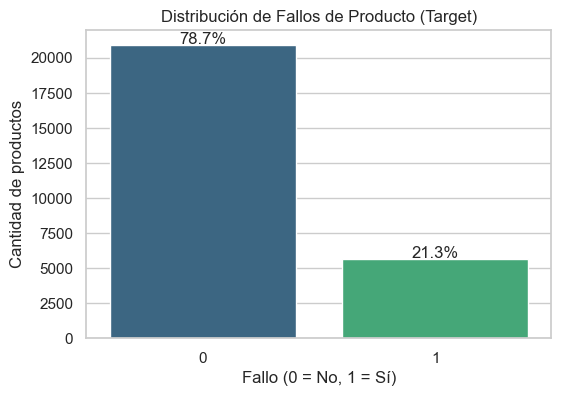

In [26]:
# Gráfico de distribución de la clase objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data_train, x='failure', palette='viridis')
plt.title('Distribución de Fallos de Producto (Target)')
plt.xlabel('Fallo (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de productos')

# Añadir porcentajes sobre las barras
total = len(data_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), size=12)

plt.show()

### 3. Exploración de Variables Categóricas
Analizamos cuántos códigos de producto distintos tenemos y sus atributos asociados. Esto es clave para asegurarnos de que el modelo pueda generalizar bien hacia códigos de producto que nunca ha visto.

In [27]:
# Variables categóricas en train vs test
cat_cols = data_train.select_dtypes(include=['object']).columns

print("Valores únicos en Train:")
for col in cat_cols:
    print(f"- {col}: {data_train[col].unique()}")

print("\nValores únicos en Test:")
for col in cat_cols:
    if col in data_test.columns:
        print(f"- {col}: {data_test[col].unique()}")

Valores únicos en Train:
- product_code: ['A' 'B' 'C' 'D' 'E']
- attribute_0: ['material_7' 'material_5']
- attribute_1: ['material_8' 'material_5' 'material_6']

Valores únicos en Test:
- product_code: ['F' 'G' 'H' 'I']
- attribute_0: ['material_5' 'material_7']
- attribute_1: ['material_6' 'material_7' 'material_5']


### 📝 Conclusiones del EDA y Decisiones de Modelado

El Análisis Exploratorio de Datos ha revelado tres factores críticos que condicionarán nuestra estrategia de modelado:

1. **Falta de solapamiento en categorías:** Los conjuntos de *Train* y *Test* contienen códigos de producto (`product_code`) completamente distintos, e incluso hay materiales en el test que no aparecen en el entrenamiento. Esto nos obliga a **eliminar los códigos de producto** de las variables predictoras, ya que el modelo no podrá aprender de ellos y solo generarían ruido o sobreajuste (*overfitting*).
2. **Presencia de valores nulos:** Existe un porcentaje notable de mediciones faltantes en los sensores. Para evitar introducir sesgos con técnicas de imputación (como rellenar con la media), utilizaremos algoritmos como **LightGBM**, que tienen la capacidad nativa de gestionar y aprender de los valores nulos directamente.
3. **Desbalanceo de la variable objetivo:** La gran mayoría de los productos superan las pruebas sin fallar. Este fuerte desbalanceo confirma que el *Accuracy* será una métrica engañosa, por lo que evaluaremos nuestros modelos basándonos estrictamente en el **ROC-AUC**, priorizando así la correcta estimación de las probabilidades de fallo.

## ⚙️ TAREA 1: Predicción de Fallos en Productos
El objetivo principal es utilizar el histórico de datos para predecir si nuevos productos fallarán, basándonos en los resultados de sus pruebas de laboratorio.

**Archivos de datos proporcionados:**
* 📄 `train.csv`: Conjunto de datos de entrenamiento. Incluye las características y la variable objetivo (`failure`).
* 📄 `test.csv`: Conjunto de datos de evaluación. La tarea consiste en predecir la **probabilidad** (*likelihood*) de que cada identificador (`id`) experimente un fallo.


**Modelo y evaluación**

Se empleará un modelo de machine learning basado en **boosting de árboles de decisiones**. En este modelo se entrenan árboles de decisión de manera secuencial y cada nuevo árbol intenta corregir los errores cometidos por los anteriores. Específicamente, utilizaremos **LightGBM**, un modelo altamente eficiente que destaca por su velocidad y su excelente capacidad nativa para manejar variables categóricas.

Se seguirá la siguiente estrategia para garantizar que nuestro modelo sea robusto y evitar overfitting:

- **Tratamiento de variables categóricas**: Convertimos las columnas de texto al tipo category de Pandas. Esto permite que LightGBM aplique su propio algoritmo de agrupamiento óptimo, evitando tener que transformar los datos manualmente (por ejemplo, con One-Hot Encoding).

- **Validación Cruzada Estratificada (Stratified K-Fold)**: Entrenaremos el modelo utilizando 5 particiones (folds). Al ser estratificada, nos aseguramos de que cada partición mantenga la misma proporción de fallos que el dataset original.

- **Evaluación de métricas**: En cada fold, el modelo se detendrá automáticamente si deja de mejorar (Early Stopping) y se evaluará utilizando tanto el Accuracy (Precisión) como el ROC-AUC (Área Bajo la Curva), siendo esta última la métrica más adecuada para problemas de probabilidades.

- **Predicción combinada (Ensembling**)**: Las predicciones finales sobre el conjunto de test serán el promedio exacto de las probabilidades calculadas por los 5 modelos entrenados, generando así un resultado mucho más estable.

In [30]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Preparar features y target
X = data_train.drop(columns=["failure", "product_code", "id"], errors='ignore')
y = data_train["failure"]
X_test = data_test.drop(columns=["id", "product_code"], errors='ignore')


# Encontrar todas las columnas que son texto (object)
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Convertirlas al tipo 'category' de Pandas en ambos datasets
for col in categorical_features:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 2. Inicializar el StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_predictions_sum = np.zeros(len(X_test))

print("Iniciando entrenamiento por Folds...\n")

# 3. Entrenar el modelo iterando por los folds
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Crear datasets nativos de LightGBM 
    # (Al ser tipo 'category', LightGBM ya sabe que son categóricas automáticamente)
    lgb_train_fold = lgb.Dataset(X_train, label=y_train)
    lgb_val_fold = lgb.Dataset(X_val, label=y_val, reference=lgb_train_fold)
    
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'verbose': -1
    }
    
    model = lgb.train(
        params, 
        lgb_train_fold, 
        valid_sets=[lgb_val_fold], 
        callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
    )  

    # --- EVALUACIÓN DEL FOLD ---
    val_preds_prob = model.predict(X_val, num_iteration=model.best_iteration)
    val_preds_binary = (val_preds_prob > 0.5).astype(int)
    
    fold_acc = accuracy_score(y_val, val_preds_binary)
    fold_auc = roc_auc_score(y_val, val_preds_prob)
    print(f"Fold {fold + 1} | Accuracy: {fold_acc:.4f} | ROC-AUC: {fold_auc:.4f}")
    
    # --- PREDICCIÓN DEL TEST ---
    test_predictions_sum += model.predict(X_test, num_iteration=model.best_iteration)

# 4. Promediar las predicciones del test
final_test_predictions_prob = test_predictions_sum / skf.get_n_splits()

print("\n¡Entrenamiento completado con variables categóricas!")

Iniciando entrenamiento por Folds...

Fold 1 | Accuracy: 0.7879 | ROC-AUC: 0.5875
Fold 2 | Accuracy: 0.7872 | ROC-AUC: 0.5770
Fold 3 | Accuracy: 0.7874 | ROC-AUC: 0.5914
Fold 4 | Accuracy: 0.7874 | ROC-AUC: 0.5789
Fold 5 | Accuracy: 0.7874 | ROC-AUC: 0.5815

¡Entrenamiento completado con variables categóricas!


**Análisis de Resultados Preliminares**

- **Capacidad Predictiva Limitada (ROC-AUC ~0.58):** El valor de AUC es bajo (apenas superior al 0.5 del azar), lo que indica que al modelo le está costando mucho encontrar patrones claros que distingan qué productos fallarán y cuáles no con las variables actuales.

- **La "Trampa" del Accuracy (~78.8%):** Aunque el Accuracy parece alto, es engañoso. Dado que la mayoría de los productos no fallan, el modelo acierta simplemente prediciendo la clase mayoritaria (0), pero falla al detectar los casos críticos (1). Por eso confiamos más en el ROC-AUC.

- **Estabilidad del Entrenamiento:** A pesar del bajo rendimiento, los resultados son muy consistentes entre los 5 folds (baja varianza estándar), lo que confirma que el modelo es robusto y no está sufriendo de sobreajuste (overfitting) en una partición específica.

## 📊 TAREA 2: Evaluación del *Data Drift*
En MLOps, es crucial garantizar que el modelo no se degrade en producción. Para ello, evaluaremos si existe *Data Drift* (desviación de datos) entre el conjunto de entrenamiento y el de prueba. 

Para probar esta hipótesis mediante **Validación Adversaria**, seguiremos estos pasos:

1. **Limpieza inicial:**
   * Eliminar la columna `failure` de `train.csv` (ya que no existe en el test).
   * Eliminar la columna `id` en ambos conjuntos, puesto que es un identificador artificial y no una característica física del producto.
2. **Combinación de datos:** Unir ambos conjuntos (`train.csv` y `test.csv`) en un único *DataFrame*.
3. **Creación del *Target* Adversario:** Añadir una nueva columna objetivo al *DataFrame* combinado donde:
   * Las filas provenientes de `train.csv` se etiquetan con **`0`**.
   * Las filas provenientes de `test.csv` se etiquetan con **`1`**.
4. **Entrenamiento del detector:** Entrenar un modelo de clasificación binaria para predecir si un registro dado pertenece al entrenamiento o al test.

> 💡 **Hipótesis y Reflexión:**
> * **Si el modelo es capaz de separarlos (Alta precisión):** Significa que hay un claro *Data Drift*. Los datos nuevos tienen características o distribuciones distintas a los históricos.
> * **Si el modelo se confunde (Precisión ~50%):** Significa que no hay *Data Drift*. A ojos del modelo, ambos conjuntos de datos son indistinguibles y homogéneos.

In [ ]:
data_train_2 = data_train.copy().drop(columns=["id", "failure", "product_code", "attribute_0", "attribute_1"], errors='ignore')   
data_test_2 = data_test.copy().drop(columns=["id", "product_code", "attribute_0", "attribute_1"], errors='ignore')
# combinar train y test en una sola tabla

data_combined = pd.concat([data_train_2, data_test_2], axis=0).reset_index(drop=True)
display(data_combined.head())





,loading,attribute_2,attribute_3,measurement_0,measurement_1,measurement_2,measurement_3,measurement_4,measurement_5,measurement_6,...,measurement_8,measurement_9,measurement_10,measurement_11,measurement_12,measurement_13,measurement_14,measurement_15,measurement_16,measurement_17
0,80.10,9,5,7,8,4,18.040,12.518,15.748,19.292,...,20.155,10.672,15.859,17.594,15.193,15.029,NaN,13.034,14.684,764.100
1,84.89,9,5,14,3,3,18.213,11.540,17.717,17.893,...,17.889,12.448,17.947,17.915,11.755,14.732,15.425,14.395,15.631,682.057
2,82.43,9,5,12,1,5,18.057,11.652,16.738,18.240,...,18.288,12.715,15.607,NaN,13.798,16.711,18.631,14.094,17.946,663.376
3,101.07,9,5,13,2,6,17.295,11.188,18.576,18.339,...,19.060,12.471,16.346,18.377,10.020,15.250,15.562,16.154,17.172,826.282
4,188.06,9,5,9,2,8,19.346,12.950,16.990,15.746,...,18.093,10.337,17.082,19.932,12.428,16.182,12.760,13.153,16.412,579.885


In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMClassifier

# 1. Crear la variable objetivo para el Data Drift (0 para Train, 1 para Test)
y_drift = np.concatenate([
    np.zeros(len(data_train_2)), 
    np.ones(len(data_test_2))
])

# Copiamos el dataset combinado para prepararlo
X_drift = data_combined.copy()

# 2. Preprocesamiento: Convertir variables de texto a números (necesario para el modelo)
cat_cols = X_drift.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_drift[cat_cols] = encoder.fit_transform(X_drift[cat_cols])

# 3. Crear el modelo "Detector de Drift"
drift_model = LGBMClassifier(random_state=42, verbose=-1)

print("Entrenando el modelo detector de Data Drift...\n")

# 4. Evaluar el modelo usando Validación Cruzada con la métrica ROC-AUC
# Un ROC-AUC de 0.5 significa que adivina al azar. Un ROC-AUC de 1.0 significa que los distingue perfectamente.
cv_scores = cross_val_score(drift_model, X_drift, y_drift, cv=5, scoring='roc_auc')
mean_auc = cv_scores.mean()

print(f"Resultado de la Validación Adversaria (ROC-AUC medio): {mean_auc:.4f}\n")

# 5. Interpretación de los resultados
if mean_auc > 0.70:
    print("⚠️ ADVERTENCIA: Hay un fuerte Data Drift.")
    print("El modelo es capaz de distinguir claramente qué datos son de Train y cuáles de Test.")
elif mean_auc > 0.60:
    print("🟠 PRECAUCIÓN: Hay un ligero Data Drift.")
    print("El modelo encuentra algunas diferencias menores entre Train y Test.")
else:
    print("✅ EXCELENTE: ¡No hay Data Drift!")
    print("El modelo se confunde (el ROC-AUC está cerca de 0.50). A sus ojos, los datos de Train y Test son idénticos.")

Entrenando el modelo detector de Data Drift...

Resultado de la Validación Adversaria (ROC-AUC medio): 1.0000

⚠️ ADVERTENCIA: Hay un fuerte Data Drift.
El modelo es capaz de distinguir claramente qué datos son de Train y cuáles de Test.


## 🚨 Conclusión Tarea 2: Detección de Data Drift Extremo (Enfoque MLOps)

El resultado de nuestra Validación Adversaria ha arrojado un **ROC-AUC de 1.0000**. En el contexto de MLOps, este es un hallazgo crítico: el modelo es capaz de distinguir con un 100% de precisión si una fila pertenece al histórico (*Train*) o a los nuevos datos de producción (*Test*). 

A pesar de haber eliminado de forma proactiva el `product_code`, `attribute_0` y `attribute_1`, existe un **fuerte Data Drift**. ¿A qué se debe esto y qué implicaciones tiene?

### 🔍 1. El problema de las variables "Proxy" (Chivatos)
El enunciado de la práctica indica que los `attributes` son "fijos para cada código de producto". Aunque borramos los atributos de texto, dejamos variables numéricas como `attribute_2` y `attribute_3`. Dado que los productos del Test (F, G, H, I) son completamente distintos a los del Train (A, B, C, D, E), sus atributos numéricos fijos también son únicos. 
Para el modelo detector, `attribute_2` y `attribute_3` actúan como un "proxy" o chivato perfecto del código de producto, permitiéndole separar ambos datasets instantáneamente.

### 📉 2. Implicaciones en Producción (MLOps)
* **Caída inminente del rendimiento:** El modelo predictivo de la Tarea 1 se enfrentará en producción a un espacio de características (Feature Space) que es radicalmente distinto al que usó para aprender. Su rendimiento real será muy inferior al estimado durante la validación cruzada.
* **Falta de Generalización:** El modelo corre el riesgo de haber aprendido reglas basadas en los atributos fijos de los productos A-E, en lugar de aprender a predecir fallos basándose puramente en las mediciones de laboratorio (`measurements` y `loading`), que son las verdaderas variables dinámicas.

### 🛠️ 3. Plan de Acción Recomendado
Para construir un modelo verdaderamente generalizable y robusto:
1. **Revisión estricta de Features:** Deberíamos eliminar **todos** los atributos fijos (`attribute_2`, `attribute_3`) y entrenar el modelo predictivo **únicamente** con el `loading` y los `measurements`. 
2. **Reevaluación del Drift:** Una vez dejadas solo las mediciones puras de laboratorio, deberíamos repetir esta Validación Adversaria. Si el ROC-AUC baja a ~0.50, confirmaremos que las pruebas de laboratorio son homogéneas y el modelo será seguro de desplegar.
3. **Monitorización Continua:** Este ejercicio demuestra la necesidad absoluta de implementar *pipelines* de MLOps que calculen el Data Drift automáticamente cada vez que entren nuevos datos, generando alertas antes de que el modelo tome decisiones erróneas en el mundo real.